# Prepare

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import qutip as qt
from copy import deepcopy

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base
from fitting.fit_display_classes import GeneralFitting
from fitting.wigner import WignerAnalysis

from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

# Initialize database and config manager
db = get_database()
config_dir = 'D:/python/multimode_expts/configs'
config_manager = ConfigVersionManager(config_dir)

# Initialize job client (handle submitting and waiting for jobs)
client = JobClient()

# Check server health
health = client.health_check()
print(f"Server status: {health['status']}")
print(f"Pending jobs: {health['pending_jobs']}")

user = "connie"
print("Welcome", user)



Failed to read module file 'd:\python\multimode_expts\.pixi\envs\default\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1

Importing all classes from  D:\python\multimode_expts\experiments\dual_rail
Importing all classes from  D:\python\multimode_expts\experiments\qsim
Importing all classes from  D:\python\multimode_expts\experiments\qubit_cavity
Importing all classes from  D:\python\multimode_expts\experiments\single_qubit
Skipped top-level files ['characterization_runner.py', 'dataset.py', 'MM_base.py', 'MM_dual_rail_base.py', 'MM_rb_base.py', 'mock_hardware.py', 'sequential_experiment.py', 'sequential_experiment_classes.py', 'station.py', 'sweep_runner.py']
Server status: healthy
Pending jobs: 0
Welcome connie


In [2]:
station = MultimodeStation(
    user=user,
    # experiment_name = "250119_qec",
    # experiment_name = "260218_qsim_scramble_low_kerr",
    experiment_name = "260227_qsim_purity_shots_test",

    # storage_man_file="CFG-M1-20260212-00022",
    # hardware_config="CFG-HW-20260211-00039",
)

USE_QUEUE = True

mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soc)
# multiphoton_cfg_thisrun = AttrDict(deepcopy(mm_base_calib.multiphoton_cfg))

[STATION] Using main hardware_config version: CFG-HW-20260303-00017
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using main man1_storage_swap version: CFG-M1-20260303-00018
[STATION] Using main floquet_storage_swap version: CFG-FL-20260223-00023
Directory created at: D:\experiments\260227_qsim_purity_shots_test\plots\autocalibration_2026-03-04
Data, plots, logs will be stored in: D:\experiments\260227_qsim_purity_shots_test
Hardware configs will be read from D:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260303-00017.yml
dict_keys(['Pyro.NameServer', 'Qick101'])
QICK running on ZCU216, software version 0.2.291

Firmware configuration (built Tue Oct 15 12:06:51 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=6389.760 MHz, fabric=399.360 MHz, 32-bit DDS, range=6389.760 MHz
		DAC tile 2, blk 0 is 0_230, on JHC

In [3]:
# station.hardware_cfg

In [4]:
station.ds_storage.df

,stor_name,freq (MHz),precision (MHz),pi (mus),h_pi (mus),gain (DAC units),last_update,bs_rate_coeffs_g,bs_rate_coeffs_e,freq_coeffs_g,freq_coeffs_e,gain_range_g,gain_range_e,joint_parity,dr_ac_stark_rate,dr_jp_phase
0,M1-S1,352.804975,NaN,2.352172,1.176086,3145.0,2026-03-03 08:28:49.177729,"[-1.2836395105770435e-12, 1.562696017091276e-0...","[-1.0271277777566499e-12, 1.2180616293411382e-...","[2.416727059292405e-18, -4.5676836555436063e-1...","[1.0768268119126192e-17, -2.064263277889986e-1...","[3139.0413060452993, 4847.324955685794]","[3101.448831598782, 4790.574447085415]","[352.945277297742, 3613, 3.633305169492332, 3....",NaN,NaN
1,M1-S2,524.652154,NaN,2.066902,1.153536,4119.0,2026-03-03 08:31:21.402037,"[-1.4281651019406063e-14, 2.806388588329146e-1...","[-1.3801639995141456e-14, 2.522836838797176e-1...","[3.168997973536308e-13, -5.187532491475121e-09...","[1.5879651422642703e-13, -2.550878518704292e-0...","[3768.329130027269, 4601.31156086655]","[3734.908431473402, 4579.9722200091655]","[524.7952187148321, 4126, 3.5772383566017147, ...",NaN,NaN
2,M1-S3,700.803883,NaN,1.696505,0.848253,4754.0,2026-03-03 08:33:50.371545,"[5.6421716124194476e-14, -9.54652575391602e-10...","[5.3668931659321213e-14, -9.081097405814645e-1...","[6.6423838139356915e-15, -1.0891788247748665e-...","[7.707647124928997e-15, -1.287562445371084e-10...","[3691.6725579408326, 4750.653565000185]","[3675.6253949570655, 4747.5907746229]","[700.9623452312223, 3898, 3.5574971282155756, ...",NaN,NaN
3,M1-S4,880.746852,NaN,2.347447,1.173723,5724.0,2026-03-03 08:36:23.348135,"[1.3074330883632018e-13, -3.895577532599537e-0...","[1.0440734314418517e-13, -3.1165658095145888e-...","[-1.7911015967743975e-13, 5.255316029156036e-0...","[1.183456340477642e-13, -3.4848271304432547e-0...","[7130.408130290509, 7845.801085058587]","[7106.808810897533, 7826.805864093215]",NaN,NaN,NaN
4,M1-S5,1057.057548,NaN,2.833119,1.416560,6123.0,2026-02-21 15:08:17.529746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,M1-S6,1248.744497,NaN,2.236056,0.902242,10382.0,2026-03-03 08:38:55.422709,"[-1.3966876001204708e-16, 6.9291826510581826e-...","[-2.6880391715732103e-16, 1.302538630495037e-1...","[3.8362619693507795e-16, -1.8777580937514096e-...","[4.2919235562169526e-16, -2.0702799090883976e-...","[10695.78483095193, 14045.482358218112]","[10727.35496738184, 14406.811373274053]","[1248.8666467863163, 11486, 3.482493636565513,...",NaN,NaN
6,M1-S7,1426.863489,NaN,2.983754,1.491877,9840.0,2026-03-03 08:41:26.225786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,M1-S8,-1.000000,-1.00,-1.000000,-1.000000,-1.0,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,M1-S9,-1.000000,-1.00,-1.000000,-1.000000,-1.0,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,M1-S10,-1.000000,-1.00,-1.000000,-1.000000,-1.0,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
from slab.datamanagement import SlabFile
import json
import os

"""Reopen saved data"""
def prev_data(expt_path, filename=None):
    temp_data_file = expt_path
    if filename is not None: temp_data_file = os.path.join(expt_path, filename)
    with SlabFile(temp_data_file) as a:
        attrs = dict()
        for key in list(a.attrs):
            attrs.update({key:json.loads(a.attrs[key])})
        keys = list(a)
        temp_data = dict()
        for key in keys:
            temp_data.update({key:np.array(a[key])})
        print(f'Extracted data and attrs {list(a.attrs)}')
    return temp_data, attrs

# Qsim Wigner Tomography

In [14]:
# station.ds_storage.update_pi('M1-S5', 0.0)
# station.ds_storage.update_h_pi('M1-S5', 0.0)
station.ds_storage.df

,stor_name,freq (MHz),precision (MHz),pi (mus),h_pi (mus),gain (DAC units),last_update,bs_rate_coeffs_g,bs_rate_coeffs_e,freq_coeffs_g,freq_coeffs_e,gain_range_g,gain_range_e,joint_parity
0,M1-S1,352.805558,NaN,2.352172,1.176086,3165,2026-02-18 21:44:59.812198,"[6.2959968690631556e-12, -6.699368273526967e-0...","[7.383865302907885e-12, -7.797184007194762e-08...","[-1.6577518042124867e-15, 2.756361265923283e-1...","[1.1142942637280849e-14, -1.652314658401054e-1...","[3160.238886646501, 4483.339453881508]","[3133.336503716933, 4444.2063605122485]","[352.94571265363584, 3573, 3.6038623637400553,..."
1,M1-S2,524.626255,NaN,2.307073,1.153536,3747,2026-02-18 21:44:24.462327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M1-S3,700.807420,NaN,1.696505,0.848253,4717,2026-02-05 12:06:37.153292,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M1-S4,880.757057,NaN,1.865498,0.932749,7158,2026-02-05 14:12:50.143204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M1-S5,1056.917751,NaN,0.000000,0.000000,2493,2026-02-19 10:40:07.770525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,M1-S6,1248.717666,NaN,1.804485,0.902242,12761,2026-02-05 12:09:41.772552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,M1-S7,1426.868265,NaN,2.983754,1.491877,9834,2026-02-18 11:48:35.511677,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,M1-S8,-1.000000,-1.00,-1.000000,-1.000000,-1,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,M1-S9,-1.000000,-1.00,-1.000000,-1.000000,-1,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,M1-S10,-1.000000,-1.00,-1.000000,-1.000000,-1,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# station.ds_floquet.update_len('M1-S5', 0.0)
station.ds_floquet.df

,stor_name,pi_frac,freq (MHz),gain (DAC units),len (mus),ramp_sigma (mus),phase_from_M1-S1 (deg),phase_from_M1-S2 (deg),phase_from_M1-S3 (deg),phase_from_M1-S4 (deg),phase_from_M1-S5 (deg),phase_from_M1-S6 (deg),phase_from_M1-S7 (deg),last_update
0,M1-S1,50,352.811637,2752,0.048025,0.005008,0.000000,3.124849,-0.010766,0.0,0.0,0.000000,-7.868584,2026-02-19 10:27:35.307187
1,M1-S2,30,524.626255,3747,0.076902,0.005008,-3.492669,0.000000,-3.957270,0.0,0.0,-2.695980,-6.049181,2026-02-13 15:57:45.546711
2,M1-S3,40,700.842547,4717,0.042413,0.005008,0.524244,4.753306,0.000000,0.0,0.0,-0.697611,-2.604314,2026-02-18 16:44:06.095805
3,M1-S4,30,880.757057,7158,0.062183,0.005008,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,2026-02-13 15:57:45.553742
4,M1-S5,30,1056.917751,2493,0.000000,0.005008,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,2026-02-18 14:54:26.383476
5,M1-S6,40,1248.717666,12761,0.045112,0.005008,0.000000,3.591544,1.160044,0.0,0.0,0.000000,-0.994739,2026-02-13 15:57:45.559742
6,M1-S7,30,1426.840595,9020,0.085157,0.005008,8.814188,4.529378,1.914683,0.0,0.0,1.045383,0.000000,2026-02-19 10:29:56.121814


## Reopen old data

In [ ]:
# Reopen old data
import pickle

pkl_files = [
# 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00091_expt.pkl',
# 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00096_expt.pkl',
# 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00100_expt.pkl',
# 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00102_expt.pkl',
# 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00104_expt.pkl',
# 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00105_expt.pkl',

# 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00106_expt.pkl',
# 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00107_expt.pkl',
# 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00108_expt.pkl',

# 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00109_expt.pkl',
# 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00111_expt.pkl',
# 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00113_expt.pkl',

'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00023_expt.pkl',
'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00024_expt.pkl',
'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00025_expt.pkl',

        # 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00068_expt.pkl',
]

# pkl_files = [
#     [
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00083_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00068_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00074_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00082_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00094_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00103_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00008_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00017_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00023_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00028_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00033_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00036_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00040_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00045_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00048_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00052_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00057_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00060_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00064_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00069_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00074_expt.pkl'], 
#     [
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00085_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00070_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00076_expt.pkl', 
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00087_expt.pkl',  
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00097_expt.pkl',   
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00106_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00012_expt.pkl', 
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00019_expt.pkl',  
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00025_expt.pkl',   
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00030_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00034_expt.pkl', 
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00037_expt.pkl',  
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00042_expt.pkl',   
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00046_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00049_expt.pkl', 
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00054_expt.pkl',  
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00058_expt.pkl',   
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00061_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00066_expt.pkl', 
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00070_expt.pkl',  
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00076_expt.pkl'],
#     [
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00087_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00072_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00078_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00091_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00100_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00003_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00015_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00021_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00026_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00032_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00035_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00038_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00044_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00047_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00050_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00056_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00059_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00062_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00068_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00072_expt.pkl',
#         'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00078_expt.pkl'],
# ]
# pkl_files = pkl_files[0]

# pkl_files = sorted(pkl_files)
print(pkl_files)

cutoff = 15
ideal_state = (qt.coherent(cutoff, 1.0)).unit()
# floquet_cycles = np.arange(1, 50, step=5)

outer_param = []
purity_list = []
rho_list = []
W_fits = []
x_vecs = []

for i, pkl_file in enumerate(pkl_files):
    with open(pkl_file, "rb") as f:
        test_wigner = pickle.load(f)
        test_wigner.analyze_wigner(mode_state_num=cutoff, debug=True)
        test_wigner.display(rotate=True, initial_state=ideal_state, mode_state_num=cutoff, station=station, save_fig=False)
        print(test_wigner.cfg.expt.displacement_path)

        if len(pkl_files) == 1:
            plt.show()
        else: plt.clf()

        wigner_outputs = test_wigner.data["wigner_outputs"]

        # print(wigner_outputs["pe_plus"][0, 0, :])
        # print(wigner_outputs["pe_minus"][0, 0, :])

        rho = wigner_outputs['rho'][0][0]
        rho = np.array(rho)
        outer_param.append(test_wigner.outer_params)
        x_vecs.append(wigner_outputs['alpha_wigner'][0][0])
        # ax.pcolor(*np.meshgrid(np.arange(np.shape(rho)[0]),
        #                        np.arange(np.shape(rho)[0])), 
        #           np.abs(rho),
        #           cmap='viridis', vmin=0, vmax=1)
        # purity = 
        purity_list.append(np.trace(np.matmul(rho, rho)))
        rho_list.append(rho)
        W_fits.append(wigner_outputs['W_fit'][0][0])

['D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00023_expt.pkl', 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00024_expt.pkl', 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00025_expt.pkl']
num shots start, end: 0 2000
0 None
shape (301, 2000)
max parity: 0.8892998843499792
max parity before scaling: 0.9071296486542014
Analyzing for floquet_cycle=0, dummy=None
D:\experiments\260227_qsim_purity_shots_test\optimized_displacements.npy
num shots start, end: 0 2000
0 None
shape (301, 2000)
max parity: 0.9099461444056693
max parity before scaling: 0.9281898500102728
Analyzing for floquet_cycle=0, dummy=None
D:\experiments\260227_qsim_purity_shots_test\optimized_displacements.npy
num shots start, end: 0 2000
0 None
shape (301, 2000)
max parity: 0.9033997692660602
max parity before scaling: 0.921512225190055
Analyzing for floquet_cycle=0, dummy=None
D:\experiments\260227_qsim_purity_shots_test\optimized_displaceme

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

1


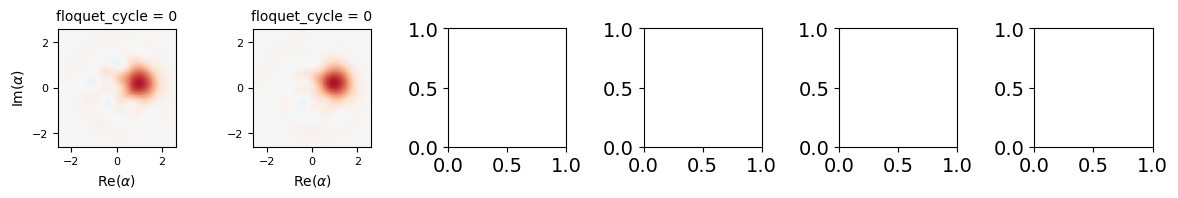

In [14]:
_n = len(pkl_files)
num_cols = 6
num_rows = _n//num_cols if (_n % num_cols == 0) else _n//num_cols + 1
print(num_rows)
fig, ax = plt.subplots(num_rows, num_cols, figsize = (num_cols * 2, num_rows * 2))
# _n -=1
for i in range(_n):
    W_fit = W_fits[i]
    r = i // num_cols
    c = i % num_cols
    vmin = -2/np.pi
    vmax = 2/np.pi
    x_vec = x_vecs[i]
    this_ax = ax[r, c] if num_rows > 1 else ax[c]
    this_ax.set_aspect('equal')
    this_ax.pcolormesh(x_vec, x_vec, W_fit, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    if c == 0:
        this_ax.set_ylabel(r'Im($\alpha$)', fontsize=10)
    if r == num_rows - 1:
        this_ax.set_xlabel(r'Re($\alpha$)', fontsize=10)
    this_ax.set_title(f"{test_wigner.outer_param} = {outer_param[i][0]}", fontsize=10)
    this_ax.tick_params(axis='both', which='major', labelsize=8)
    
fig.tight_layout()
plt.show()

1


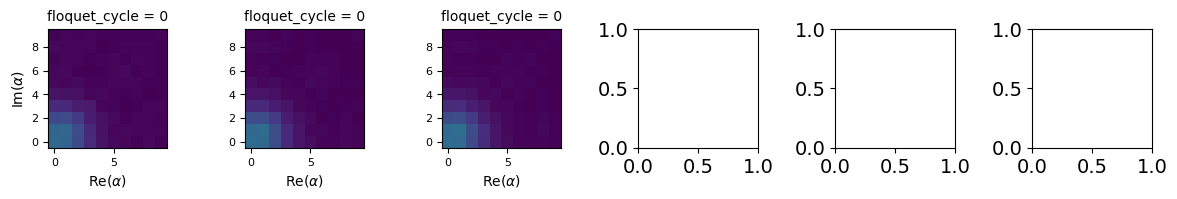

In [21]:
_n = len(pkl_files)
num_cols = 6
num_rows = _n//num_cols if (_n % num_cols == 0) else _n//num_cols + 1
print(num_rows)
fig, ax = plt.subplots(num_rows,num_cols, figsize = (num_cols * 2, num_rows * 2))
for i in range(_n):
    rho = rho_list[i]
    r = i // num_cols
    c = i % num_cols
    vmin = 0
    vmax = 1
    x_vec = np.arange(np.shape(rho)[0])
    this_ax = ax[r, c] if num_rows > 1 else ax[c]
    this_ax.set_aspect('equal')
    this_ax.pcolormesh(x_vec, x_vec, np.abs(rho), cmap='viridis', vmin=vmin, vmax=vmax)
    if c == 0:
        this_ax.set_ylabel(r'Im($\alpha$)', fontsize=10)
    if r == num_rows - 1:
        this_ax.set_xlabel(r'Re($\alpha$)', fontsize=10)
    this_ax.set_title(f"{test_wigner.outer_param} = {outer_param[i][0]}", fontsize=10)
    this_ax.tick_params(axis='both', which='major', labelsize=8)
    
fig.tight_layout()
plt.show()


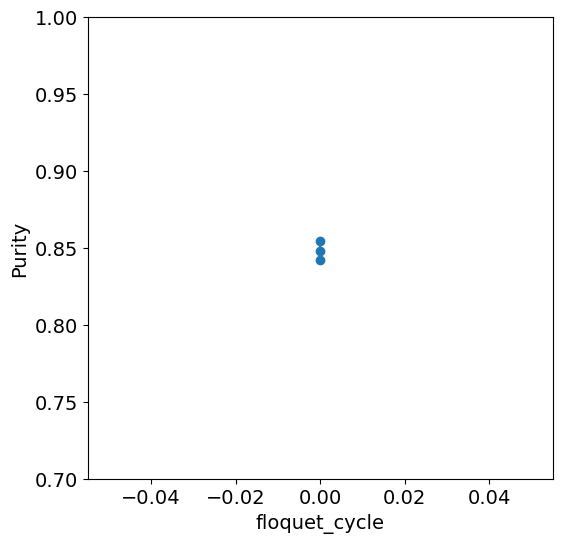

In [24]:
fig, ax = plt.subplots(figsize=(6,6))

ax.plot(outer_param, np.abs(purity_list), 'o-')
ax.set_xlabel(f'{test_wigner.outer_param}')
ax.set_ylabel("Purity")
# ax.set_ylim(0.5, 1)
ax.set_ylim(0.7, 1.0)
plt.show()

## Plot for multiple ro_stor

In [39]:
# Reopen old data
import pickle

all_pkl_files = [
    [
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00083_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00091_expt.pkl',
        # 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00068_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00074_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00082_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00094_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00103_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00008_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00017_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00023_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00028_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00033_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00036_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00040_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00045_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00048_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00052_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00057_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00060_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00064_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00069_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00074_expt.pkl'], 
    [
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00085_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00096_expt.pkl',
        # 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00070_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00076_expt.pkl', 
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00087_expt.pkl',  
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00097_expt.pkl',   
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00106_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00012_expt.pkl', 
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00019_expt.pkl',  
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00025_expt.pkl',   
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00030_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00034_expt.pkl', 
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00037_expt.pkl',  
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00042_expt.pkl',   
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00046_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00049_expt.pkl', 
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00054_expt.pkl',  
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00058_expt.pkl',   
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00061_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00066_expt.pkl', 
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00070_expt.pkl',  
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00076_expt.pkl'],
    [
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00087_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00097_expt.pkl',
        # 'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00072_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00078_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00091_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260225-00100_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00003_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00015_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00021_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00026_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00032_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00035_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00038_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00044_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00047_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00050_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00056_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00059_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00062_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00068_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00072_expt.pkl',
        'D:\\experiments\\260218_qsim_scramble_low_kerr\\expt_objs\\JOB-20260226-00078_expt.pkl'],
]

ro_purities = []
all_outer_params = []

for i_ro_stor, ro_stor in enumerate([0, 1, 7]):
    pkl_files = all_pkl_files[i_ro_stor] # man

    # pkl_files = sorted(pkl_files)
    # print(pkl_files)

    cutoff = 10
    ideal_state = (qt.coherent(cutoff, 1.0)).unit()
    # floquet_cycles = np.arange(1, 50, step=5)

    outer_param = []
    purity_list = []
    rho_list = []
    W_fits = []
    x_vecs = []


    for i, pkl_file in enumerate(pkl_files):
        with open(pkl_file, "rb") as f:
            test_wigner = pickle.load(f)

            old_gain_to_alpha = station.hardware_cfg.device.manipulate.gain_to_alpha[0]
            new_gain_to_alpha = 0.00026802675830382277

            old_alpha_scale = station.hardware_cfg.device.manipulate.alpha_scale[0]
            # new_alpha_scale = 0.8746985532746205 *
            new_alpha_scale = 0.80

            # test_wigner.analyze_wigner(mode_state_num=cutoff, debug=True)
            test_wigner.analyze_wigner_temp(mode_state_num=cutoff, rescale_gain_to_alpha=old_gain_to_alpha / new_gain_to_alpha, rescale_alpha_scale=new_alpha_scale / old_alpha_scale, debug=True)
            test_wigner.display(rotate=True, initial_state=ideal_state, mode_state_num=cutoff, station=station, save_fig=False)

            assert test_wigner.cfg.expt.ro_stor == ro_stor, f"Expected ro_stor {ro_stor} but got {test_wigner.cfg.expt.ro_stor} from cfg.extp.ro_stor"

            if len(pkl_files) == 1:
                plt.show()
            else: plt.clf()

            wigner_outputs = test_wigner.data["wigner_outputs"]

            # print(wigner_outputs["pe_plus"][0, 0, :])
            # print(wigner_outputs["pe_minus"][0, 0, :])

            rho = wigner_outputs['rho'][0][0]
            rho = np.array(rho)
            outer_param.append(test_wigner.outer_params)
            x_vecs.append(wigner_outputs['alpha_wigner'][0][0])
            # ax.pcolor(*np.meshgrid(np.arange(np.shape(rho)[0]),
            #                        np.arange(np.shape(rho)[0])), 
            #           np.abs(rho),
            #           cmap='viridis', vmin=0, vmax=1)
            # purity = 
            purity_list.append(np.trace(np.matmul(rho, rho)))
            rho_list.append(rho)
            W_fits.append(wigner_outputs['W_fit'][0][0])
    ro_purities.append(purity_list)
    all_outer_params.append(outer_param)

num shots start, end: 0 200
0 None
shape (201, 200)
max parity: 1.2276785714285707
max parity before scaling: 0.9821428571428567
Analyzing for floquet_cycle=0, dummy=None
num shots start, end: 0 200
1 None
shape (201, 200)
max parity: 1.1808723419224347
max parity before scaling: 0.9446978735379478
Analyzing for floquet_cycle=1, dummy=None
num shots start, end: 0 200
6 None
shape (201, 200)
max parity: 1.139758912013188
max parity before scaling: 0.9118071296105503
Analyzing for floquet_cycle=6, dummy=None
num shots start, end: 0 200
11 None
shape (201, 200)
max parity: 1.112122788761707
max parity before scaling: 0.8896982310093656
Analyzing for floquet_cycle=11, dummy=None
num shots start, end: 0 200
16 None
shape (201, 200)
max parity: 1.2352039737898963
max parity before scaling: 0.9881631790319172
Analyzing for floquet_cycle=16, dummy=None
num shots start, end: 0 200
21 None
shape (201, 200)
max parity: 1.2087824984147115
max parity before scaling: 0.9670259987317692
Analyzing for

D:\python\multimode_expts\fitting\wigner.py:373: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 2, figsize=(10, 10))


num shots start, end: 0 200
0 None
shape (201, 200)
max parity: 1.2366520100502514
max parity before scaling: 0.9893216080402012
Analyzing for floquet_cycle=0, dummy=None
num shots start, end: 0 200
1 None
shape (201, 200)
max parity: 1.187797376314663
max parity before scaling: 0.9502379010517304
Analyzing for floquet_cycle=1, dummy=None
num shots start, end: 0 200
6 None
shape (201, 200)
max parity: 1.1655161755615087
max parity before scaling: 0.932412940449207
Analyzing for floquet_cycle=6, dummy=None
num shots start, end: 0 200
11 None
shape (201, 200)
max parity: 1.18906828465652
max parity before scaling: 0.951254627725216
Analyzing for floquet_cycle=11, dummy=None
num shots start, end: 0 200
16 None
shape (201, 200)
max parity: 1.2352039737898963
max parity before scaling: 0.9881631790319172
Analyzing for floquet_cycle=16, dummy=None
num shots start, end: 0 200
21 None
shape (201, 200)
max parity: 1.17575565419573
max parity before scaling: 0.9406045233565841
Analyzing for floq

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

...

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


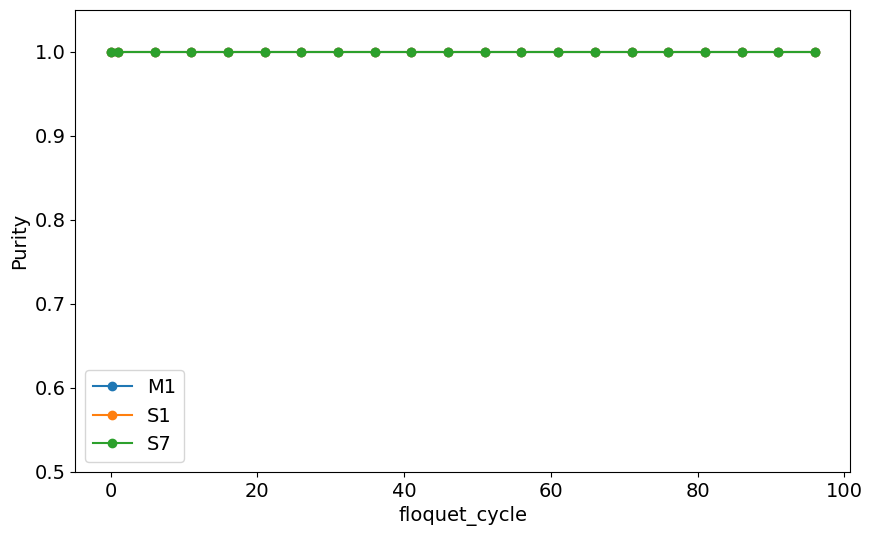

In [40]:
plt.figure()
plt.plot(all_outer_params[0], ro_purities[0], 'o-', label='M1')
plt.plot(all_outer_params[1], ro_purities[1], 'o-', label='S1')
plt.plot(all_outer_params[2], ro_purities[2], 'o-', label='S7')
plt.xlabel(f'{test_wigner.outer_param}')
plt.ylabel("Purity")
plt.legend()
plt.ylim(0.5, 1.05)
plt.show()

In [ ]:
# test_wigner = meas.QsimWignerBaseExperiment(config_file=station.hardware_config_file, expt_params=kerr_wait_wigner_defaults)
# test_wigner.data = wigner.data
# test_wigner.outer_params = wigner.outer_params
# test_wigner.inner_params = wigner.inner_params
# test_wigner.outer_param = wigner.outer_param
# test_wigner.inner_param = wigner.inner_param
# test_wigner.pulse_correction = wigner.pulse_correction
# test_wigner.cfg = deepcopy(wigner.cfg)

# test_wigner.analyze_wigner(mode_state_num=10)

## Plot for different sampling number of shots

In [23]:
# Reopen old data
import pickle

pkl_files = [
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00023_expt.pkl',
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00024_expt.pkl',
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00025_expt.pkl',
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00031_expt.pkl',
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00034_expt.pkl',
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00037_expt.pkl'
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260303-00073_expt.pkl'
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260303-00073_expt.pkl',
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260303-00075_expt.pkl',
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260303-00077_expt.pkl',
# 'D:\\experiments\\260214_qsim\\expt_objs\\JOB-20260302-00032_expt.pkl',
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260304-00011_expt.pkl',
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260304-00013_expt.pkl', 
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260304-00017_expt.pkl',
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260304-00018_expt.pkl', 
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260304-00019_expt.pkl', 
'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260304-00021_expt.pkl',
'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260304-00022_expt.pkl', 
'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260304-00023_expt.pkl', 
]

# pkl_files = sorted(pkl_files)
print(pkl_files)

cutoff = 8
ideal_state = (qt.coherent(cutoff, 1.0)).unit()
# floquet_cycles = np.arange(1, 50, step=5)

all_outer_param = []
all_purity_list = []
all_rho_list = []
all_W_fits = []
all_x_vecs = []

for i, pkl_file in enumerate(pkl_files):
    all_outer_param.append([])
    all_purity_list.append([])
    all_rho_list.append([])
    all_W_fits.append([])
    all_x_vecs.append([])

    with open(pkl_file, "rb") as f:
        test_wigner = pickle.load(f)
        print(test_wigner.cfg.expt.displacement_path)

        num_shots_sample_list = np.arange(100, test_wigner.cfg.expt.reps + 1, step=100)

        
        outer_param = all_outer_param[-1]
        purity_list = all_purity_list[-1]
        rho_list = all_rho_list[-1]
        W_fits = all_W_fits[-1]
        x_vecs = all_x_vecs[-1]

        for num_shots_sample in num_shots_sample_list:
            print(f"Analyzing with {num_shots_sample} shots...")

            test_wigner.analyze_wigner_temp(mode_state_num=cutoff, debug=True, num_shots_sample=num_shots_sample)
            test_wigner.display(rotate=True, initial_state=ideal_state, mode_state_num=cutoff, station=station, save_fig=False)


            if len(pkl_files) == 1:
                plt.show()
            else: plt.clf()

            wigner_outputs = test_wigner.data["wigner_outputs"]

            # print(wigner_outputs["pe_plus"][0, 0, :])
            # print(wigner_outputs["pe_minus"][0, 0, :])

            rho = wigner_outputs['rho'][0][0]
            rho = np.array(rho)
            outer_param.append(test_wigner.outer_params)
            x_vecs.append(wigner_outputs['alpha_wigner'][0][0])
            # ax.pcolor(*np.meshgrid(np.arange(np.shape(rho)[0]),
            #                        np.arange(np.shape(rho)[0])), 
            #           np.abs(rho),
            #           cmap='viridis', vmin=0, vmax=1)
            # purity = 
            purity_list.append(np.trace(np.matmul(rho, rho)))
            rho_list.append(rho)
            W_fits.append(wigner_outputs['W_fit'][0][0])

['D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260304-00021_expt.pkl', 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260304-00022_expt.pkl', 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260304-00023_expt.pkl']
D:\experiments\260227_qsim_purity_shots_test\optimized_displacements_1.npy
Analyzing with 100 shots...
num shots start, end: 0 100
0 None
shape (201, 100)
max parity: 0.9465188575316942
max parity before scaling: 0.8279186753301195
Analyzing for floquet_cycle=0, dummy=None
Analyzing with 200 shots...
num shots start, end: 0 200
0 None
shape (201, 200)
max parity: 0.9525094832122747
max parity before scaling: 0.8331586669461332
Analyzing for floquet_cycle=0, dummy=None
Analyzing with 300 shots...
num shots start, end: 0 300
0 None
shape (201, 300)
max parity: 0.978468861161456
max parity before scaling: 0.8558652972821912
Analyzing for floquet_cycle=0, dummy=None
Analyzing with 400 shots...
num shots start, end: 0 400
0 

D:\python\multimode_expts\fitting\wigner.py:373: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 2, figsize=(10, 10))


Analyzing with 200 shots...
num shots start, end: 0 200
0 None
shape (201, 200)
max parity: 1.0783126225044617
max parity before scaling: 0.9431984908824147
Analyzing for floquet_cycle=0, dummy=None
Analyzing with 300 shots...
num shots start, end: 0 300
0 None
shape (201, 300)
max parity: 1.0743188720507417
max parity before scaling: 0.9397051631384059
Analyzing for floquet_cycle=0, dummy=None
Analyzing with 400 shots...
num shots start, end: 0 400
0 None
shape (201, 400)
max parity: 1.066331371143301
max parity before scaling: 0.9327185076503878
Analyzing for floquet_cycle=0, dummy=None
Analyzing with 500 shots...
num shots start, end: 0 500
0 None
shape (201, 500)
max parity: 1.049557619237676
max parity before scaling: 0.9180465311255502
Analyzing for floquet_cycle=0, dummy=None
Analyzing with 600 shots...
num shots start, end: 0 600
0 None
shape (201, 600)
max parity: 1.0503563693284201
max parity before scaling: 0.9187451966743522
Analyzing for floquet_cycle=0, dummy=None
Analyzi

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

...

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


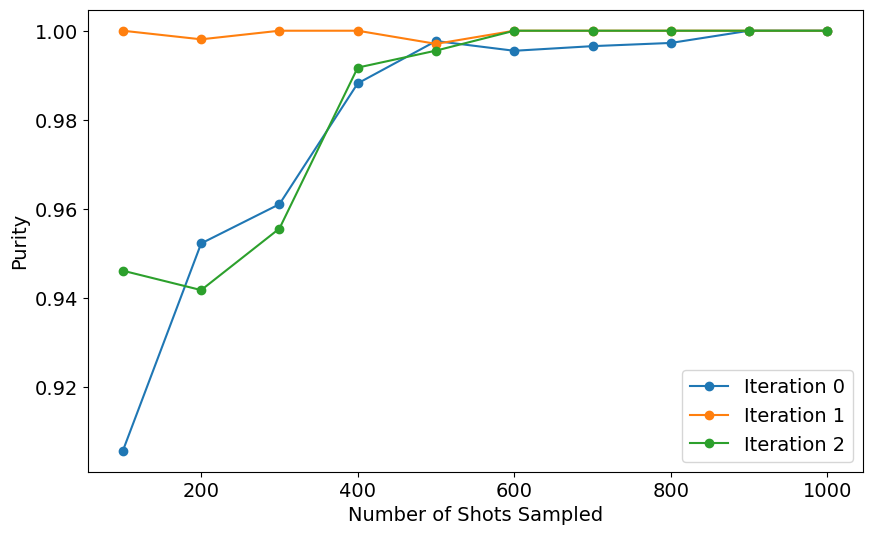

In [24]:
plt.figure()
for i in range(len(all_outer_param)):
    plt.plot(num_shots_sample_list, all_purity_list[i], 'o-', label=f'Iteration {i}')
plt.xlabel("Number of Shots Sampled")
plt.ylabel("Purity")
plt.legend()
# plt.ylim(0.5, 1)
plt.show()